# 第3周｜线性回归与统计解释

学习目标：回归系数、调整、残差、置信区间、关联不等于因果。

__数据：默认使用官方 PRIME-CVD 5 万人数据__（`python run.py download` 下载，来源与 MD5 核验记录在 `data/raw/manifest.json`）。把 `MODE` 改成 `"demo"` 可以切换到离线演示数据，但演示数据是另外生成的，**不是 PRIME-CVD**，结果不能当作官方结果。

本周验收：解释年龄每增加10岁对应的平均收缩压差异。

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
from IPython.display import display

# 从项目根目录、notebooks目录或其他项目内目录启动均可。
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run.py").exists()), None)
if ROOT is None:
    raise RuntimeError("请在解压后的项目目录中启动 Jupyter。")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from primecvd.common import load_config, provenance_label
from primecvd.pipeline import prepare
from primecvd.splitting import select_split

MODE = "official"  # 官方数据；离线练习或跑测试时可改为 "demo"（演示数据不是 PRIME-CVD）
cfg = load_config(ROOT / "configs" / f"{MODE}.json")
cfg["output_dir"] = f"outputs/notebooks_{MODE}"
print(provenance_label(cfg))
df, splits = prepare(cfg)
train = select_split(df, splits, "train")
valid = select_split(df, splits, "valid")
# 不创建test DataFrame；模型试验只使用train和valid。
print("队列、训练集、验证集：", len(df), len(train), len(valid))

# 命令行绘图模块采用无窗口后端；在Notebook中显式启用行内图像。
get_ipython().run_line_magic("matplotlib", "inline")
from primecvd import pubplot as pp   # 与精讲篇相同的顶刊作图风格（在启用行内图像之后设置）
pp.setup()

OFFICIAL SOURCE FILES / 官方下载文件
队列、训练集、验证集： 50000 35000 7500


## 线性回归回答什么？
练习问题：在固定模型中的BMI和吸烟类别后，年龄每增加10岁，平均收缩压差多少？这是条件关联，不是干预年龄的因果效应。HC3是对异方差更稳健的标准误形式，不会自动修复模型形式错误。

In [2]:
import statsmodels.api as sm
from primecvd.basics import design_basics
X = design_basics(train)
model = sm.OLS(train.SBP, X).fit(cov_type="HC3")
display(pd.DataFrame({"coefficient":model.params, "CI_low":model.conf_int()[0], "CI_high":model.conf_int()[1]}))

,coefficient,CI_low,CI_high
intercept,72.269653,71.217106,73.322200
Age_per10,4.037905,3.916673,4.159138
BMI_per5,5.350511,5.201181,5.499842
smoking_ex,1.829893,1.421194,2.238591
smoking_current,4.065956,3.565997,4.565914


`Age_per10`和`BMI_per5`是事先规定的临床单位缩放，不是利用全队列均值做的标准化。截距代表各数值预测变量为0且吸烟为参考类别的数学值，未必是现实患者。

验证集RMSE (mmHg)： 14.196810777887057


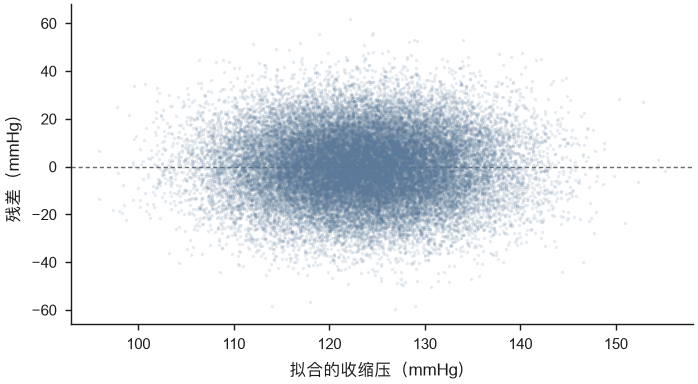

In [3]:
pred = model.predict(design_basics(valid))
print("验证集RMSE (mmHg)：", float(np.sqrt(np.mean((valid.SBP-pred)**2))))
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=pp.size(pp.ONE_HALF, 62))
# 3.5 万个点：点要小、要半透明，否则重叠成一团；rasterized 让导出的 PDF 不会过大
ax.scatter(model.fittedvalues, model.resid, s=2, alpha=0.15, color=pp.NEUTRAL, lw=0, rasterized=True)
pp.ref_line(ax, 0, axis="y")
ax.set(xlabel="拟合的收缩压（mmHg）", ylabel="残差（mmHg）")
plt.show()

## 独立练习
写出一个系数的完整解释，包含单位和调整的其他变量。观察残差图，思考是否存在非线性或方差不恒定。增加二次年龄项作为探索，但不能通过测试集决定是否保留。

---
本周复盘：请用自己的话记录一个学会的概念、一个发现的错误和一个待解决问题。

特别提醒：系数是条件关联；不把统计调整自动称为消除混杂。